# Predictive Maintenance from Sensor Logs

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Classifiers & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, f1_score, accuracy_score, 
                             precision_score, recall_score)

# Visual aesthetics
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('tab10')
import warnings
warnings.filterwarnings('ignore')

print("All predictive maintenance libraries successfully imported!")

All predictive maintenance libraries successfully imported!


## 2. Sensor Telemetry Data & EDA

In [2]:
# Ingest sensor telemetry logs
df = pd.read_csv('predictive_maintenance_sensors.csv')
print(f"Sensor Dataset Dimensions: {df.shape[0]} logs, {df.shape[1]} attributes\n")

# Display first 5 telemetry records
df.head()

Sensor Dataset Dimensions: 1500 logs, 9 attributes



,Product_Type,Air_Temperature_K,Process_Temperature_K,Rotational_Speed_rpm,Torque_Nm,Tool_Wear_min,Vibration_mm_s,Machine_Failure,Failure_Type
0,L,295.00,303.83,1540.2,39.45,95.8,4.05,0,No Failure
1,H,304.58,313.69,1622.0,30.78,235.2,4.88,0,No Failure
2,M,297.22,307.82,1491.0,40.07,54.2,5.20,0,No Failure
3,M,296.71,305.76,1216.6,25.21,146.9,6.04,0,No Failure
4,L,302.05,312.51,1462.3,35.12,103.9,2.69,0,No Failure


In [3]:
# Data schema and statistical summary
print("=== Telemetry Schema & Health Check ===")
df.info()

print("\n=== Summary Statistics of Physical Sensor Readings ===")
df.describe().round(2)

=== Telemetry Schema & Health Check ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product_Type           1500 non-null   object 
 1   Air_Temperature_K      1500 non-null   float64
 2   Process_Temperature_K  1500 non-null   float64
 3   Rotational_Speed_rpm   1500 non-null   float64
 4   Torque_Nm              1500 non-null   float64
 5   Tool_Wear_min          1500 non-null   float64
 6   Vibration_mm_s         1500 non-null   float64
 7   Machine_Failure        1500 non-null   int64  
 8   Failure_Type           1500 non-null   object 
dtypes: float64(6), int64(1), object(2)
memory usage: 105.6+ KB

=== Summary Statistics of Physical Sensor Readings ===


,Air_Temperature_K,Process_Temperature_K,Rotational_Speed_rpm,Torque_Nm,Tool_Wear_min,Vibration_mm_s,Machine_Failure
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,300.06,310.05,1531.73,39.55,120.44,4.50,0.13
std,1.97,2.22,173.05,10.39,68.47,1.16,0.34
min,293.96,303.38,982.10,7.79,0.00,-0.21,0.00
25%,298.71,308.53,1420.88,32.34,62.50,3.75,0.00
50%,300.04,310.06,1534.50,39.52,120.30,4.52,0.00
75%,301.36,311.47,1652.55,46.83,179.10,5.27,0.00
max,306.39,317.56,2082.80,75.29,239.90,8.29,1.00


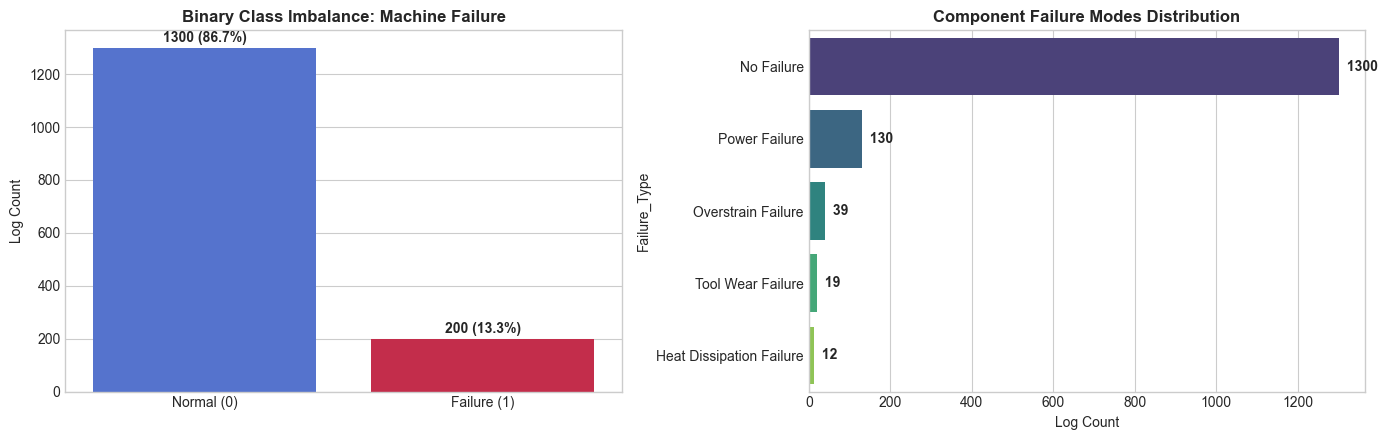

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Binary Failure Imbalance
failure_counts = df['Machine_Failure'].value_counts()
sns.barplot(x=['Normal (0)', 'Failure (1)'], y=failure_counts.values, palette=['royalblue', 'crimson'], ax=axes[0])
axes[0].set_title('Binary Class Imbalance: Machine Failure', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Log Count')
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
                     (p.get_x() + p.get_width() / 2, p.get_height() + 20),
                     ha='center', fontsize=10, fontweight='bold')

# Multi-class Component Failure Modes
mode_counts = df['Failure_Type'].value_counts()
sns.barplot(x=mode_counts.values, y=mode_counts.index, palette='viridis', ax=axes[1])
axes[1].set_title('Component Failure Modes Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log Count')
for p in axes[1].patches:
    axes[1].annotate(f" {int(p.get_width())}",
                     (p.get_width() + 10, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

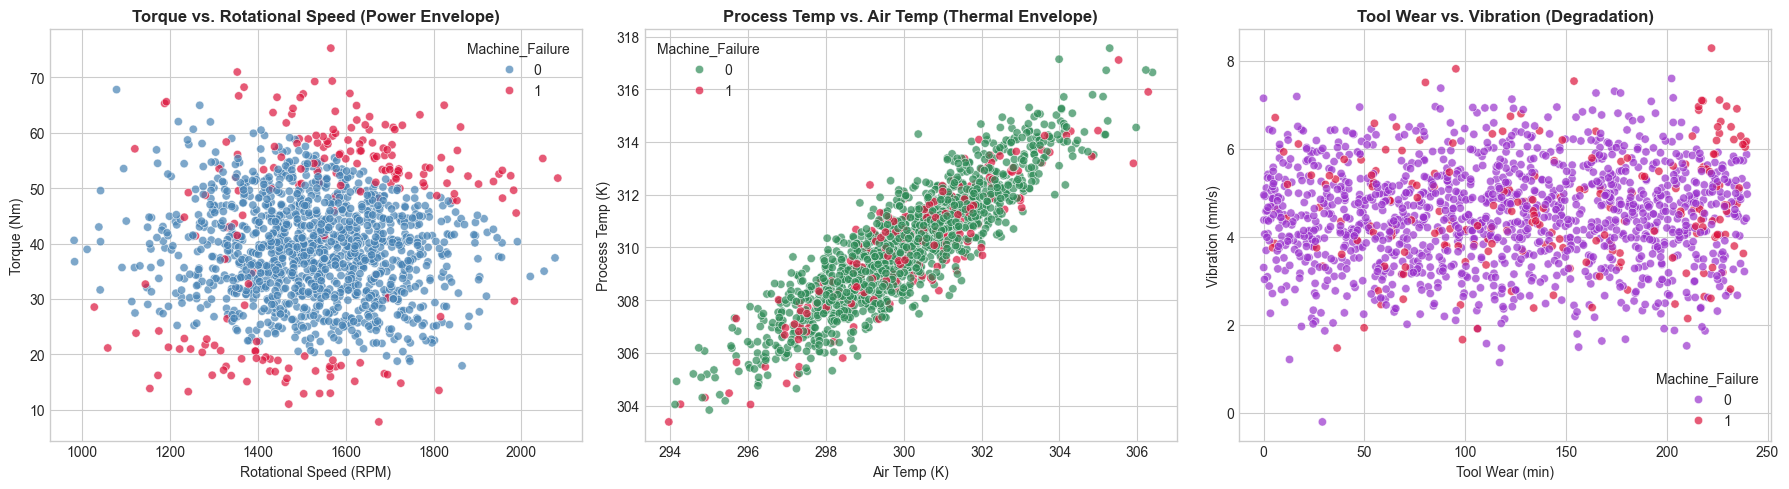

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Torque vs Rotational Speed (Power Envelope)
sns.scatterplot(data=df, x='Rotational_Speed_rpm', y='Torque_Nm', hue='Machine_Failure',
                palette={0: 'steelblue', 1: 'crimson'}, alpha=0.7, ax=axes[0])
axes[0].set_title('Torque vs. Rotational Speed (Power Envelope)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rotational Speed (RPM)')
axes[0].set_ylabel('Torque (Nm)')

# 2. Process Temp vs Air Temp (Thermal Envelope)
sns.scatterplot(data=df, x='Air_Temperature_K', y='Process_Temperature_K', hue='Machine_Failure',
                palette={0: 'seagreen', 1: 'crimson'}, alpha=0.7, ax=axes[1])
axes[1].set_title('Process Temp vs. Air Temp (Thermal Envelope)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Air Temp (K)')
axes[1].set_ylabel('Process Temp (K)')

# 3. Tool Wear vs Vibration (Mechanical Degradation)
sns.scatterplot(data=df, x='Tool_Wear_min', y='Vibration_mm_s', hue='Machine_Failure',
                palette={0: 'darkorchid', 1: 'crimson'}, alpha=0.7, ax=axes[2])
axes[2].set_title('Tool Wear vs. Vibration (Degradation)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tool Wear (min)')
axes[2].set_ylabel('Vibration (mm/s)')

plt.tight_layout()
plt.show()

## 3. Feature Engineering (Thermal & Mechanical Indices)

In [6]:
df_eng = df.copy()

# 1. Temperature difference (Thermal Dissipation)
df_eng['Temp_Difference_K'] = (df_eng['Process_Temperature_K'] - df_eng['Air_Temperature_K']).round(2)

# 2. Mechanical Power in Watts (P = Torque * angular velocity)
df_eng['Mechanical_Power_W'] = (df_eng['Torque_Nm'] * (df_eng['Rotational_Speed_rpm'] * 2 * np.pi / 60)).round(1)

# 3. Overstrain Index (Tool Wear * Torque)
df_eng['Overstrain_Index'] = (df_eng['Tool_Wear_min'] * df_eng['Torque_Nm']).round(1)

# 4. Vibration Wear Interaction
df_eng['Vibration_Wear_Product'] = (df_eng['Tool_Wear_min'] * df_eng['Vibration_mm_s']).round(1)

# Display newly engineered physical features
print(f"Engineered Telemetry Dimensions: {df_eng.shape}")
df_eng[['Temp_Difference_K', 'Mechanical_Power_W', 'Overstrain_Index', 'Vibration_Wear_Product']].head()

Engineered Telemetry Dimensions: (1500, 13)


,Temp_Difference_K,Mechanical_Power_W,Overstrain_Index,Vibration_Wear_Product
0,8.83,6362.9,3779.3,388.0
1,9.11,5228.2,7239.5,1147.8
2,10.60,6256.4,2171.8,281.8
3,9.05,3211.8,3703.3,887.3
4,10.46,5378.0,3649.0,279.5


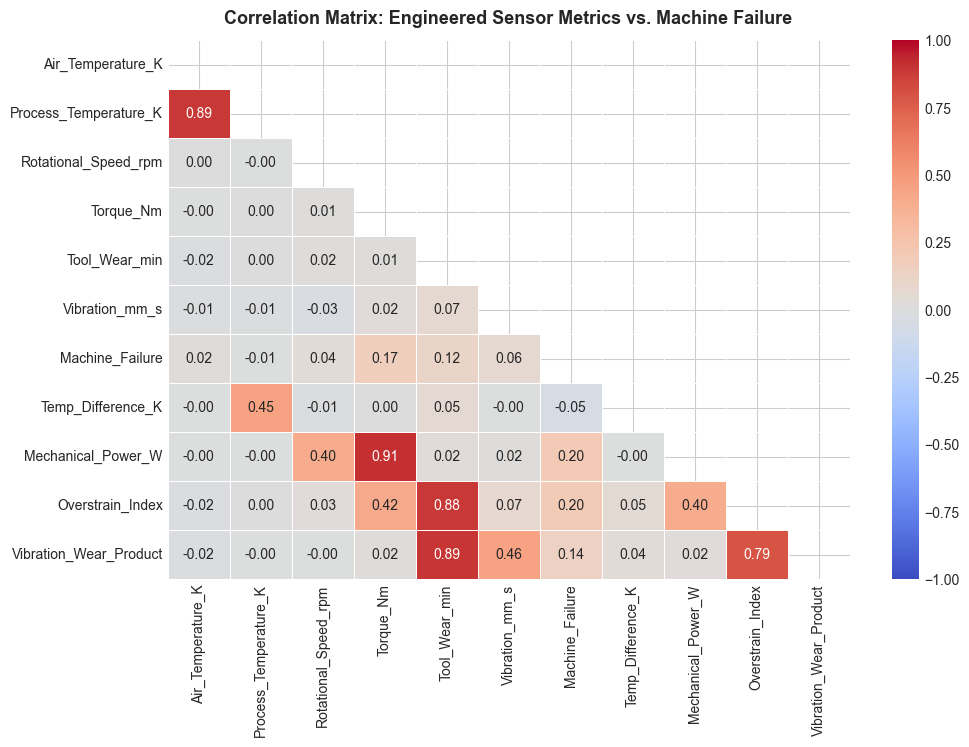

In [7]:
plt.figure(figsize=(11, 7))
num_corr = df_eng.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(num_corr, dtype=bool))
sns.heatmap(num_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix: Engineered Sensor Metrics vs. Machine Failure', fontsize=13, fontweight='bold', pad=12)
plt.show()

## 4. Preprocessing & Class Imbalance Handling

In [8]:
# Features for Binary Classification
X = df_eng.drop(columns=['Machine_Failure', 'Failure_Type'])
# One-hot encode Product_Type
X = pd.get_dummies(X, columns=['Product_Type'], drop_first=True, dtype=int)
y = df_eng['Machine_Failure']

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"Training set: {X_train.shape[0]} logs (Failures: {y_train.sum()} / {y_train.sum()/len(y_train)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]} logs (Failures: {y_test.sum()} / {y_test.sum()/len(y_test)*100:.1f}%)")

Training set: 1200 logs (Failures: 160 / 13.3%)
Testing set:  300 logs (Failures: 40 / 13.3%)


## 5. Binary Failure Classification Models

In [9]:
classifiers = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=120, learning_rate=0.08, max_depth=4, random_state=42)
}

predictions = {}
probabilities = {}

for name, clf in classifiers.items():
    if 'Logistic' in name or 'Neighbors' in name:
        clf.fit(X_train_scaled, y_train)
        preds = clf.predict(X_test_scaled)
        probs = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        probs = clf.predict_proba(X_test)[:, 1]
        
    predictions[name] = preds
    probabilities[name] = probs
    print(f"Trained: {name:25s}")

Trained: Logistic Regression      
Trained: K-Nearest Neighbors      
Trained: Decision Tree            


Trained: Random Forest            


Trained: Gradient Boosting        


In [10]:
eval_records = []

for name in classifiers.keys():
    preds = predictions[name]
    probs = probabilities[name]
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)
    
    eval_records.append({
        'Classifier': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall (Sensitivity)': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    })

eval_df = pd.DataFrame(eval_records).sort_values(by='F1-Score', ascending=False)
print("=== Predictive Maintenance Binary Classification Benchmark ===")
eval_df

=== Predictive Maintenance Binary Classification Benchmark ===


,Classifier,Accuracy,Precision,Recall (Sensitivity),F1-Score,ROC-AUC
2,Decision Tree,1.0000,1.0000,1.000,1.0000,1.0000
4,Gradient Boosting,1.0000,1.0000,1.000,1.0000,1.0000
3,Random Forest,0.9900,1.0000,0.925,0.9610,0.9991
1,K-Nearest Neighbors,0.9133,1.0000,0.350,0.5185,0.9088
0,Logistic Regression,0.7533,0.2821,0.550,0.3729,0.6829


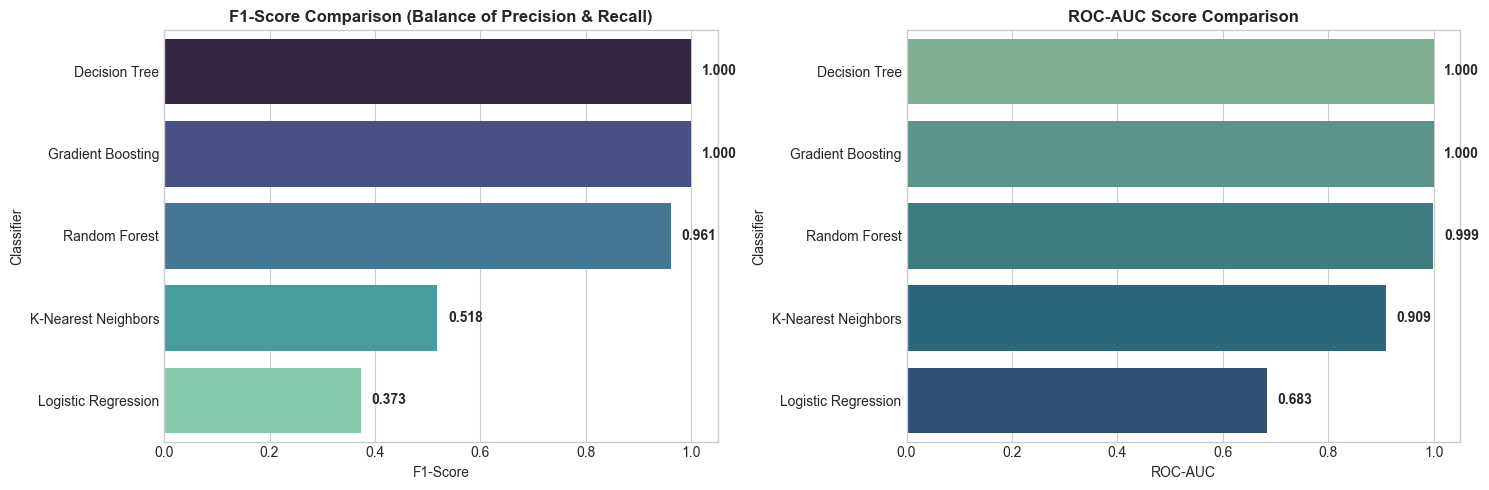

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# F1-Score Comparison
sns.barplot(data=eval_df, x='F1-Score', y='Classifier', palette='mako', ax=axes[0])
axes[0].set_title('F1-Score Comparison (Balance of Precision & Recall)', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1.05)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_width():.3f}", 
                     (p.get_width() + 0.02, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=10, fontweight='bold')

# ROC-AUC Comparison
sns.barplot(data=eval_df, x='ROC-AUC', y='Classifier', palette='crest', ax=axes[1])
axes[1].set_title('ROC-AUC Score Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 1.05)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_width():.3f}", 
                     (p.get_width() + 0.02, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Diagnostic Evaluation (Confusion Matrix, ROC & PR Curves)

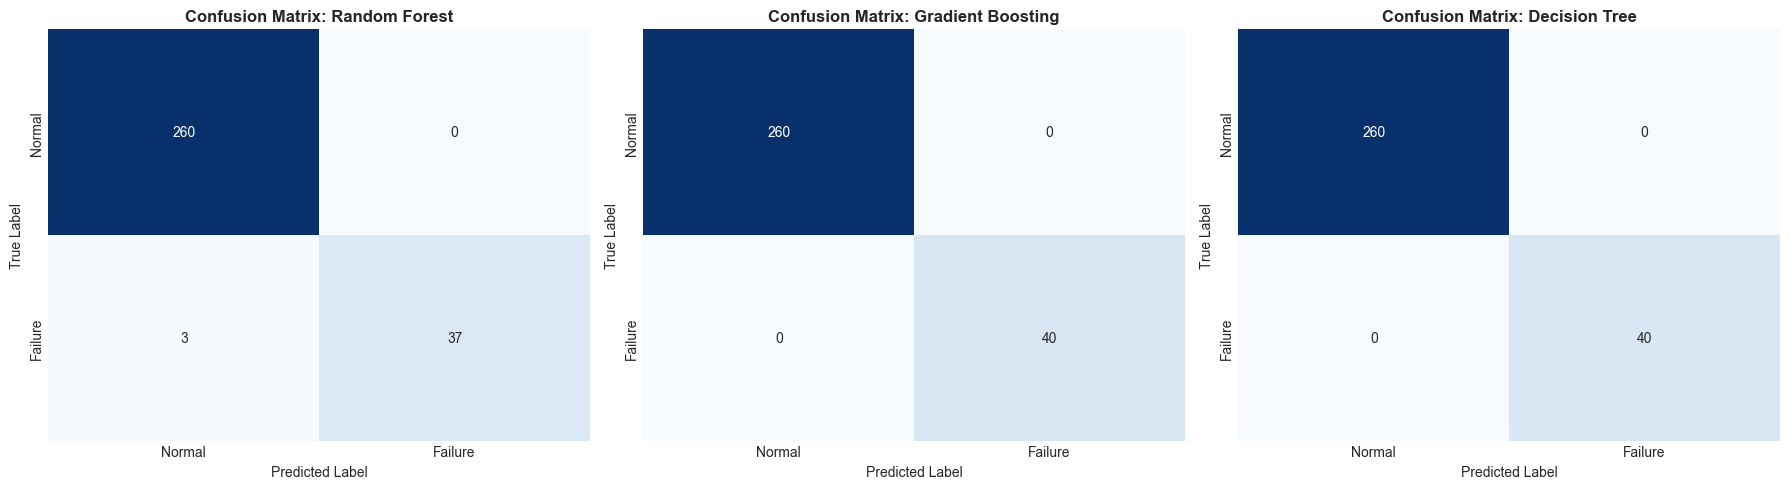

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

inspect_models = ['Random Forest', 'Gradient Boosting', 'Decision Tree']

for idx, m_name in enumerate(inspect_models):
    cm = confusion_matrix(y_test, predictions[m_name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal', 'Failure'],
                yticklabels=['Normal', 'Failure'],
                ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix: {m_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

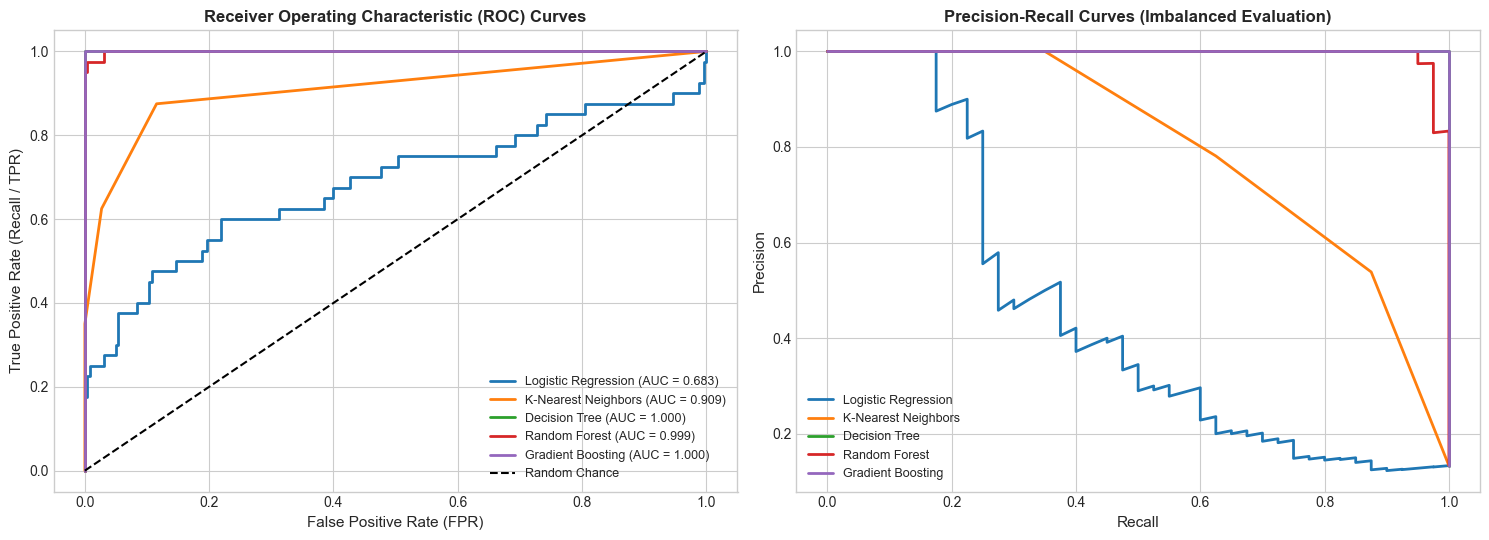

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ROC Curves
for name in classifiers.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_val = roc_auc_score(y_test, probabilities[name])
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_val:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall / TPR)', fontsize=11)
axes[0].legend(loc='lower right', fontsize=9)

# Precision-Recall Curves
for name in classifiers.keys():
    prec, rec, _ = precision_recall_curve(y_test, probabilities[name])
    axes[1].plot(rec, prec, lw=2, label=f"{name}")

axes[1].set_title('Precision-Recall Curves (Imbalanced Evaluation)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

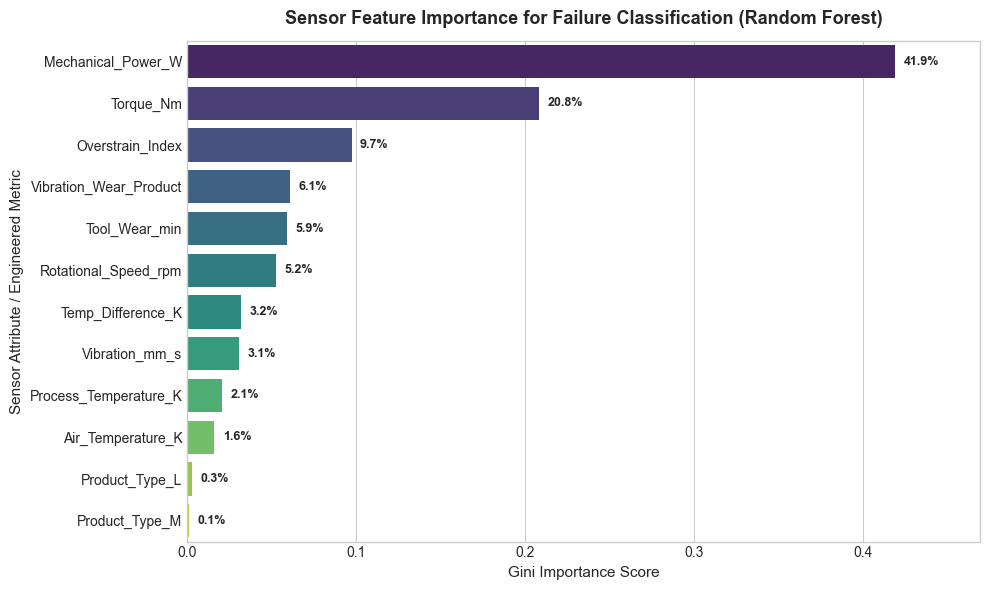

In [14]:
rf_model = classifiers['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Sensor Feature Importance for Failure Classification (Random Forest)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Gini Importance Score', fontsize=11)
plt.ylabel('Sensor Attribute / Engineered Metric', fontsize=11)
for idx, val in enumerate(feat_imp.values):
    plt.text(val + 0.005, idx, f"{val*100:.1f}%", va='center', fontsize=9, fontweight='bold')
plt.xlim(0, max(feat_imp.values) + 0.05)
plt.tight_layout()
plt.show()

## 7. Multi-Class Component Failure Classification

In [15]:
# Target for Multi-Class Classification
y_multi = df_eng['Failure_Type']
label_encoder = LabelEncoder()
y_multi_encoded = label_encoder.fit_transform(y_multi)

# Stratified Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi_encoded, test_size=0.20, random_state=42, stratify=y_multi_encoded
)

# Multi-class Random Forest with balanced class weights
rf_multi = RandomForestClassifier(n_estimators=150, class_weight='balanced', max_depth=12, random_state=42)
rf_multi.fit(X_train_m, y_train_m)
y_pred_m = rf_multi.predict(X_test_m)

print("=== Multi-Class Component Failure Classification Report ===")
print(classification_report(y_test_m, y_pred_m, target_names=label_encoder.classes_))

=== Multi-Class Component Failure Classification Report ===
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.00      0.00      0.00         2
              No Failure       0.99      1.00      0.99       260
      Overstrain Failure       1.00      1.00      1.00         8
           Power Failure       1.00      0.96      0.98        26
       Tool Wear Failure       1.00      1.00      1.00         4

                accuracy                           0.99       300
               macro avg       0.80      0.79      0.79       300
            weighted avg       0.98      0.99      0.99       300



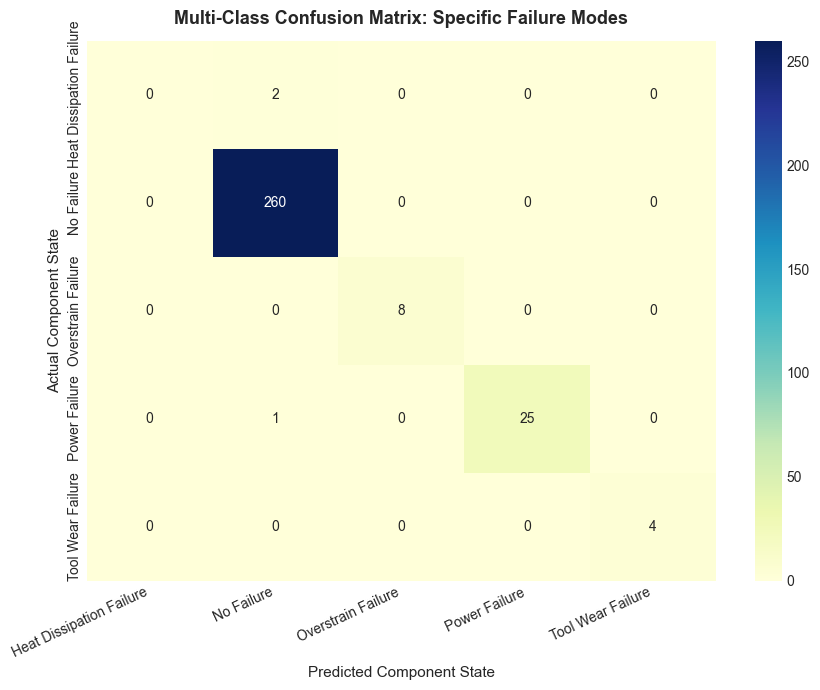

In [16]:
cm_multi = confusion_matrix(y_test_m, y_pred_m)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Multi-Class Confusion Matrix: Specific Failure Modes', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Component State', fontsize=11)
plt.ylabel('Actual Component State', fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 8. Real-Time Telemetry Diagnostic Function

In [17]:
def diagnose_machine_sensor_log(product_type, air_temp, process_temp, rot_speed, torque, tool_wear, vibration):
    """
    Simulates edge diagnostic pipeline for streaming industrial sensor telemetry.
    """
    # Derived physical quantities
    temp_diff = process_temp - air_temp
    power = torque * (rot_speed * 2 * np.pi / 60)
    overstrain = tool_wear * torque
    vibration_wear = tool_wear * vibration
    
    input_dict = {
        'Air_Temperature_K': air_temp,
        'Process_Temperature_K': process_temp,
        'Rotational_Speed_rpm': rot_speed,
        'Torque_Nm': torque,
        'Tool_Wear_min': tool_wear,
        'Vibration_mm_s': vibration,
        'Temp_Difference_K': temp_diff,
        'Mechanical_Power_W': power,
        'Overstrain_Index': overstrain,
        'Vibration_Wear_Product': vibration_wear,
        'Product_Type_L': 1 if product_type == 'L' else 0,
        'Product_Type_M': 1 if product_type == 'M' else 0
    }
    
    input_df = pd.DataFrame([input_dict])[X.columns]
    
    # Binary failure prediction
    fail_prob = classifiers['Gradient Boosting'].predict_proba(input_df)[0, 1]
    
    # Multi-class failure mode diagnosis
    mode_pred_idx = rf_multi.predict(input_df)[0]
    predicted_mode = label_encoder.inverse_transform([mode_pred_idx])[0]
    
    if fail_prob > 0.65:
        status = "CRITICAL ALERT - IMMEDIATE SHUTDOWN REQUIRED"
        recommendation = f"Component failure imminent ({predicted_mode}). Halt spindle and dispatch maintenance technician."
    elif fail_prob > 0.30:
        status = "WARNING - ABNORMAL SENSOR TELEMETRY DETECTED"
        recommendation = f"Elevated strain detected ({predicted_mode} risk). Schedule inspection at next shift change."
    else:
        status = "HEALTHY - NORMAL OPERATIONAL PARAMETERS"
        recommendation = "All sensors within nominal specifications. Continue regular operation."
        
    return {
        'Machine Status': status,
        'Failure Probability': f"{fail_prob * 100:.1f}%",
        'Predicted Component State': predicted_mode,
        'Actionable Recommendation': recommendation
    }

# Test Case 1: Healthy normal CNC operation
normal_telemetry = {
    'product_type': 'M', 'air_temp': 298.5, 'process_temp': 308.2, 
    'rot_speed': 1520.0, 'torque': 38.5, 'tool_wear': 45.0, 'vibration': 3.8
}

# Test Case 2: Overstrain failure scenario (High tool wear + high torque)
overstrain_telemetry = {
    'product_type': 'L', 'air_temp': 301.2, 'process_temp': 311.5, 
    'rot_speed': 1480.0, 'torque': 65.0, 'tool_wear': 210.0, 'vibration': 5.2
}

print("=== Predictive Maintenance Live Telemetry Diagnostic Test ===")
print("\n--- Scenario 1: Nominal Telemetry ---")
for k, v in diagnose_machine_sensor_log(**normal_telemetry).items():
    print(f"  {k:26s}: {v}")

print("\n--- Scenario 2: High Stress Telemetry ---")
for k, v in diagnose_machine_sensor_log(**overstrain_telemetry).items():
    print(f"  {k:26s}: {v}")

=== Predictive Maintenance Live Telemetry Diagnostic Test ===

--- Scenario 1: Nominal Telemetry ---


  Machine Status            : HEALTHY - NORMAL OPERATIONAL PARAMETERS
  Failure Probability       : 0.0%
  Predicted Component State : No Failure
  Actionable Recommendation : All sensors within nominal specifications. Continue regular operation.

--- Scenario 2: High Stress Telemetry ---
  Machine Status            : CRITICAL ALERT - IMMEDIATE SHUTDOWN REQUIRED
  Failure Probability       : 100.0%
  Predicted Component State : Overstrain Failure
  Actionable Recommendation : Component failure imminent (Overstrain Failure). Halt spindle and dispatch maintenance technician.


## 9. Conclusion